# Mini_Project 1

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
print('Libraries imported successfully.')

Libraries imported successfully.


## 2. Configering Logging

In [2]:
logging.basicConfig(
    filename ='mini_project_1.log',
    level = logging.INFO,
    format = '%(asctime)s | %(levelname)s | %(message)s'
)
logging.info('project started')
print('Configering Logging successfully.')

Configering Logging successfully.


## 3. Load Dataset

In [3]:
try:
    df = pd.read_excel('data/Sample - Superstore 2019.xls', sheet_name = 'Orders')
    logging.info('loadding Sample - Superstore 2019.xls')
    print('Load Dataset successfully.')
except FileNotFoundError:
    logging.error('Sample - Superstore 2019.xls not found')
    print('File not found')
except Exception as e:
    logging.error(f'Error loading dataset: {e}')
    print(f'An error occurred: {e}')

Load Dataset successfully.


## 4. Initial Data Inspection

In [4]:
df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136


In [5]:
print('shape:',df.shape)
print('coulumns name:',df.columns)
print('data types and non_null counts:',df.info())
print('number of missing data:',df.isnull().sum())

shape: (9994, 21)
coulumns name: Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Ship Date       9994 non-null   datetime64[ns]
 4   Ship Mode       9994 non-null   object        
 5   Customer ID     9994 non-null   object        
 6   Customer Name   9994 non-null   object        
 7   Segment         9994 non-null   object        
 8   Country/Reg

##### Here we notice that there are missing values ​​in the Postal Code column, namely 11 values, and also that the data type does not match its content.

## 5. Data Cleaning

#### 5.1  Missing Values

In [6]:
df[df['Postal Code'].isnull()]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
2234,2235,CA-2019-104066,2019-12-05,2019-12-10,Standard Class,QJ-19255,Quincy Jones,Corporate,United States,Burlington,...,NaN,East,TEC-AC-10001013,Technology,Accessories,Logitech ClearChat Comfort/USB Headset H390,205.03,7,0.0,67.6599
5274,5275,CA-2017-162887,2017-11-07,2017-11-09,Second Class,SV-20785,Stewart Visinsky,Consumer,United States,Burlington,...,NaN,East,FUR-CH-10000595,Furniture,Chairs,Safco Contoured Stacking Chairs,715.20,3,0.0,178.8000
8798,8799,US-2018-150140,2018-04-06,2018-04-10,Standard Class,VM-21685,Valerie Mitchum,Home Office,United States,Burlington,...,NaN,East,TEC-PH-10002555,Technology,Phones,Nortel Meridian M5316 Digital phone,1294.75,5,0.0,336.6350
9146,9147,US-2018-165505,2018-01-23,2018-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,...,NaN,East,TEC-AC-10002926,Technology,Accessories,Logitech Wireless Marathon Mouse M705,99.98,2,0.0,42.9914
9147,9148,US-2018-165505,2018-01-23,2018-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,...,NaN,East,OFF-AR-10003477,Office Supplies,Art,4009 Highlighters,8.04,6,0.0,2.7336
9148,9149,US-2018-165505,2018-01-23,2018-01-27,Standard Class,CB-12535,Claudia Bergmann,Corporate,United States,Burlington,...,NaN,East,OFF-ST-10001526,Office Supplies,Storage,Iceberg Mobile Mega Data/Printer Cart,1564.29,13,0.0,406.7154
9386,9387,US-2019-127292,2019-01-19,2019-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,NaN,East,OFF-PA-10000157,Office Supplies,Paper,Xerox 191,79.92,4,0.0,37.5624
9387,9388,US-2019-127292,2019-01-19,2019-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,NaN,East,OFF-PA-10001970,Office Supplies,Paper,Xerox 1881,12.28,1,0.0,5.7716
9388,9389,US-2019-127292,2019-01-19,2019-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,NaN,East,OFF-AP-10000828,Office Supplies,Appliances,Avanti 4.4 Cu. Ft. Refrigerator,542.94,3,0.0,152.0232
9389,9390,US-2019-127292,2019-01-19,2019-01-23,Standard Class,RM-19375,Raymond Messe,Consumer,United States,Burlington,...,NaN,East,OFF-EN-10001509,Office Supplies,Envelopes,Poly String Tie Envelopes,2.04,1,0.0,0.9588


In [7]:
df.loc[df['Postal Code'].isnull(),['Country/Region', 'City', 'State', 'Region', 'Postal Code']]

,Country/Region,City,State,Region,Postal Code
2234,United States,Burlington,Vermont,East,NaN
5274,United States,Burlington,Vermont,East,NaN
8798,United States,Burlington,Vermont,East,NaN
9146,United States,Burlington,Vermont,East,NaN
9147,United States,Burlington,Vermont,East,NaN
9148,United States,Burlington,Vermont,East,NaN
9386,United States,Burlington,Vermont,East,NaN
9387,United States,Burlington,Vermont,East,NaN
9388,United States,Burlington,Vermont,East,NaN
9389,United States,Burlington,Vermont,East,NaN


In [8]:
df[df['State'] == 'Vermont'][['City', 'State', 'Region', 'Postal Code']]

,City,State,Region,Postal Code
2234,Burlington,Vermont,East,NaN
5274,Burlington,Vermont,East,NaN
8798,Burlington,Vermont,East,NaN
9146,Burlington,Vermont,East,NaN
9147,Burlington,Vermont,East,NaN
9148,Burlington,Vermont,East,NaN
9386,Burlington,Vermont,East,NaN
9387,Burlington,Vermont,East,NaN
9388,Burlington,Vermont,East,NaN
9389,Burlington,Vermont,East,NaN


##### We found that all 11 values ​​were:
Country/Region → United States,
City → Burlington,
State → Vermont,
Region → East;
Therefore, the data itself wasn't sufficient to determine the Postal Code.

###### So we resorted to searching for the missing value using Google Maps.

In [9]:
df['Postal Code'] = df['Postal Code'].fillna(5401)

In [10]:
df[df['State'] == 'Vermont'][['City', 'State', 'Region', 'Postal Code']]

,City,State,Region,Postal Code
2234,Burlington,Vermont,East,5401.0
5274,Burlington,Vermont,East,5401.0
8798,Burlington,Vermont,East,5401.0
9146,Burlington,Vermont,East,5401.0
9147,Burlington,Vermont,East,5401.0
9148,Burlington,Vermont,East,5401.0
9386,Burlington,Vermont,East,5401.0
9387,Burlington,Vermont,East,5401.0
9388,Burlington,Vermont,East,5401.0
9389,Burlington,Vermont,East,5401.0


In [11]:
df['Postal Code'].isnull().sum()

np.int64(0)

#### 5.2 Duplicate Data

In [12]:
df.duplicated().sum()

np.int64(0)

###### No duplicate data

#### 5.3 Inconsistent Values

In [13]:
def check_categorical_values(df, columns):
    """
    This function counts the occurrences of each unique value within the columns passed to it and prints the result.
    """
    for column in columns:
        print(f'\n{column}:')
        print(df[column].value_counts())


def check_text_format(df, column):
    """
    This function compares the number of unique values in their original state, the number after case correction, and the number after removing spaces.
    """
    original_unique = df[column].nunique()
    lower_unique = df[column].str.lower().nunique()
    stripped_unique = df[column].str.strip().nunique()

    print(f'{column}')
    print('Original unique values:', original_unique)
    print('After lower():', lower_unique)
    print('After strip():', stripped_unique)

In [14]:
categorical_columns = [
    'Ship Mode','Segment','Country/Region','City','State','Region','Category','Sub-Category'
   ]
check_categorical_values(df, categorical_columns)

for col in categorical_columns:
    check_text_format(df, col)


Ship Mode:
Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

Segment:
Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

Country/Region:
Country/Region
United States    9994
Name: count, dtype: int64

City:
City
New York City      915
Los Angeles        747
Philadelphia       537
San Francisco      510
Seattle            428
                  ... 
Glenview             1
Missouri City        1
Rochester Hills      1
Palatine             1
Manhattan            1
Name: count, Length: 531, dtype: int64

State:
State
California              2001
New York                1128
Texas                    985
Pennsylvania             587
Washington               506
Illinois                 492
Ohio                     469
Florida                  383
Michigan                 255
North Carolina           249
Arizona                  224
Virginia                 224
Georgia   

##### We made sure there were no inconsistent values.

#### 5.4 Outlier Detection

The Interquartile Range (IQR) method was used to detect potential outliers in Sales.

IQR = Q3 - Q1

Lower Bound = Q1 - 1.5 × IQR

Upper Bound = Q3 + 1.5 × IQR

In [15]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    print(f'\nColumn: {column}')
    print('Q1:', Q1)
    print('Q3:', Q3)
    print('IQR:', IQR)
    print('Lower Bound:', lower_bound)
    print('Upper Bound:', upper_bound)
    print('Number of Outliers:', len(outliers))
    
    return outliers

In [16]:
sales_outliers = detect_outliers_iqr(df, 'Sales')
quantity_outliers = detect_outliers_iqr(df, 'Quantity')
discount_outliers = detect_outliers_iqr(df, 'Discount')
profit_outliers = detect_outliers_iqr(df, 'Profit')


Column: Sales
Q1: 17.28
Q3: 209.94
IQR: 192.66
Lower Bound: -271.71000000000004
Upper Bound: 498.93
Number of Outliers: 1167

Column: Quantity
Q1: 2.0
Q3: 5.0
IQR: 3.0
Lower Bound: -2.5
Upper Bound: 9.5
Number of Outliers: 170

Column: Discount
Q1: 0.0
Q3: 0.2
IQR: 0.2
Lower Bound: -0.30000000000000004
Upper Bound: 0.5
Number of Outliers: 856

Column: Profit
Q1: 1.72875
Q3: 29.363999999999997
IQR: 27.635249999999996
Lower Bound: -39.724124999999994
Upper Bound: 70.81687499999998
Number of Outliers: 1881


### Visualization 1 — Columns of Outliers

In [17]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


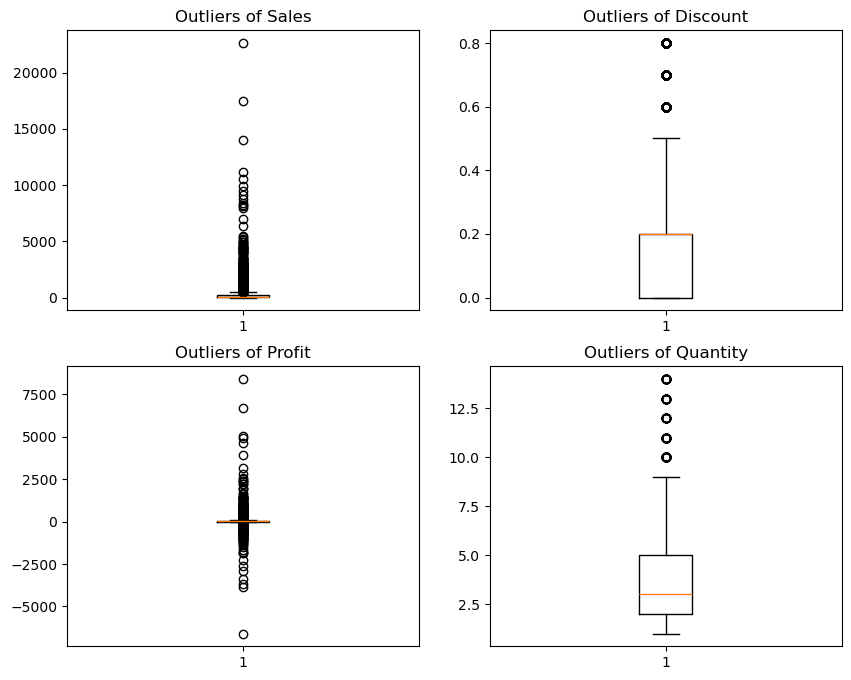

In [18]:
fig,axs = plt.subplots(2,2 , figsize = (10,8))
axs[0,0].boxplot(df['Sales'])
axs[0,0].set_title('Outliers of Sales')

axs[1,0].boxplot(df['Profit'])
axs[1,0].set_title('Outliers of Profit')

axs[0,1].boxplot(df['Discount'])
axs[0,1].set_title('Outliers of Discount')

axs[1,1].boxplot(df['Quantity'])
axs[1,1].set_title('Outliers of Quantity')

plt.style.use('seaborn-v0_8-talk')
plt.show()

##### Checking outliers for the sales column

In [19]:
df.nlargest(10, 'Sales')[
    ['Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
]

,Product Name,Sales,Quantity,Discount,Profit
2697,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784
6826,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
8153,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
2623,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
4190,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
9039,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700
4098,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755
4277,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,7,0.0,2365.9818
8488,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,0.0,2799.9840
6425,Canon imageCLASS 2200 Advanced Copier,8399.976,4,0.4,1119.9968


In [20]:
df.nsmallest(10, 'Sales')[
    ['Product Name','Sales','Quantity', 'Discount', 'Profit']
]

,Product Name,Sales,Quantity,Discount,Profit
4101,Hoover Replacement Belt for Commercial Guardsm...,0.444,1,0.8,-1.1100
9292,Acco Suede Grain Vinyl Round Ring Binder,0.556,1,0.8,-0.9452
8658,Avery Durable Slant Ring Binders With Label Ho...,0.836,1,0.8,-1.3376
4711,Avery Round Ring Poly Binders,0.852,1,0.7,-0.5964
2106,Acco 3-Hole Punch,0.876,1,0.8,-1.4016
7548,Avery Non-Stick Binders,0.898,1,0.8,-1.5715
8033,"Avery Triangle Shaped Sheet Lifters, Black, 2/...",0.984,2,0.8,-1.4760
2761,Maxell 4.7GB DVD-R 5/Pack,0.990,1,0.0,0.4356
8024,Acco Economy Flexible Poly Round Ring Binder,1.044,1,0.8,-1.8270
1332,Wilson Jones Easy Flow II Sheet Lifters,1.080,3,0.8,-1.7280


Considering the number of units sold and the product type, the figures appear commercially sound, so we will not delete them as they represent approximately 11% of our data, and we do not want to lose all that data.

##### Checking outliers for the Profit column

In [21]:
df.nlargest(10, 'Profit')[
    ['Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
]

,Product Name,Sales,Quantity,Discount,Profit
6826,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
8153,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
4190,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
9039,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700
4098,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755
2623,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
509,Fellowes PB500 Electric Punch Plastic Comb Bin...,6354.950,5,0.0,3177.4750
8488,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,0.0,2799.9840
7666,Hewlett Packard LaserJet 3310 Copier,5399.910,9,0.0,2591.9568
6520,GBC DocuBind P400 Electric Binding System,5443.960,4,0.0,2504.2216


In [22]:
df.nsmallest(10, 'Profit')[
    ['Product Name','Sales','Quantity', 'Discount', 'Profit']
]

,Product Name,Sales,Quantity,Discount,Profit
7772,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780
683,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904
9774,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928
3011,Lexmark MX611dhe Monochrome Laser Printer,2549.985,5,0.7,-3399.9800
4991,Ibico EPK-21 Electric Binding System,1889.990,5,0.8,-2929.4845
3151,Cubify CubeX 3D Printer Double Head Print,1799.994,2,0.7,-2639.9912
5310,Fellowes PB500 Electric Punch Plastic Comb Bin...,1525.188,6,0.8,-2287.7820
9639,Chromcraft Bull-Nose Wood Oval Conference Tabl...,4297.644,13,0.4,-1862.3124
1199,GBC DocuBind P400 Electric Binding System,1088.792,4,0.8,-1850.9464
2697,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784


Given the profit figures, they make commercial sense due to the discount effect and the type of product sold; therefore, we will not delete them as they represent about 18% of our data, and we do not want to lose all that data.

##### Checking outliers for the Quantity column

In [23]:
df.nlargest(10, 'Quantity')[
    ['Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
]

,Product Name,Sales,Quantity,Discount,Profit
113,"OIC Colored Binder Clips, Assorted Sizes",40.096,14,0.2,14.5348
139,Longer-Life Soft White Bulbs,43.120,14,0.0,20.6976
575,Personal Creations Ink Jet Cards and Labels,160.720,14,0.0,78.7528
660,Space Solutions Commercial Steel Shelving,724.080,14,0.2,-135.7650
1045,"Global Stack Chair without Arms, Black",254.604,14,0.3,-18.1860
1363,Cardinal EasyOpen D-Ring Binders,38.388,14,0.7,-25.5920
1429,Avery 4027 File Folder Labels for Dot Matrix P...,427.420,14,0.0,196.6132
1433,High-Back Leather Manager's Chair,1819.860,14,0.0,163.7874
1711,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",1702.120,14,0.0,510.6360
2793,Pyle PMP37LED,1075.088,14,0.2,94.0702


In [24]:
df.nsmallest(10, 'Quantity')[
    ['Product Name','Sales','Quantity', 'Discount', 'Profit']
]

,Product Name,Sales,Quantity,Discount,Profit
52,"Global Leather Task Chair, Black",89.990,1,0.0,17.0981
61,Prang Dustless Chalk Sticks,1.680,1,0.0,0.8400
70,Avery Binding System Hidden Tab Executive Styl...,4.616,1,0.2,1.7310
74,Safco Industrial Wire Shelving System,72.784,1,0.2,-18.1960
79,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",208.160,1,0.0,56.2032
82,Sortfiler Multipurpose Personal File Organizer...,21.390,1,0.0,6.2031
86,Logitech LS21 Speaker System - PC Multimedia -...,19.990,1,0.0,6.7966
91,Xerox 1995,6.480,1,0.0,3.1104
95,Flexible Leather- Look Classic Collection Ring...,5.682,1,0.7,-3.7880
107,Speck Products Candyshell Flip Case,27.992,1,0.2,2.0994


There is no abnormal number that we consider an input error.

##### Checking outliers for the Discount column

In [25]:
df.nlargest(10, 'Discount')[
    ['Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
]

,Product Name,Sales,Quantity,Discount,Profit
14,Holmes Replacement Filter for HEPA Air Cleaner...,68.810,5,0.8,-123.8580
15,Storex DuraTech Recycled Plastic Frosted Binders,2.544,3,0.8,-3.8160
75,Economy Binders,1.248,3,0.8,-1.9344
101,Avery Hidden Tab Dividers for Binding Systems,1.788,3,0.8,-3.0396
169,Kensington 7 Outlet MasterPiece Power Center,177.980,5,0.8,-453.8490
174,Kensington 7 Outlet MasterPiece HOMEOFFICE Pow...,52.448,2,0.8,-131.1200
176,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",97.264,4,0.8,-243.1600
203,Eureka Sanitaire Commercial Upright,66.284,2,0.8,-178.9668
261,Eureka Disposable Bags for Sanitaire Vibra Gro...,1.624,2,0.8,-4.4660
280,Round Ring Binders,2.080,5,0.8,-3.4320


In [26]:
df.nsmallest(10, 'Discount')[
    ['Product Name','Sales','Quantity', 'Discount', 'Profit']
]

,Product Name,Sales,Quantity,Discount,Profit
0,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714
5,Eldon Expressions Wood and Plastic Desk Access...,48.86,7,0.0,14.1694
6,Newell 322,7.28,4,0.0,1.9656
9,Belkin F5C206VTEL 6 Outlet Surge,114.90,5,0.0,34.4700
16,"Stur-D-Stor Shelving, Vertical 5-Shelf: 72""H x...",665.88,6,0.0,13.3176
17,Fellowes Super Stor/Drawer,55.50,2,0.0,9.9900
18,Newell 341,8.56,2,0.0,2.4824
21,Newell 318,19.46,7,0.0,5.0596


Also, the discount rates are very commercially sound and there are no errors in the values.

#### 5.4.1 Outlier Handling Decision

As shown above, the outliers in Sales, Profit, Discount, and Quantity are commercially valid data points, not data-entry errors, and together they represent a meaningful share of total records. Deleting them would remove real business information. Our chosen **handling strategy is therefore to retain them**, rather than delete or transform them.

#### 5.5 Data Types
The columns were classified according to their analytical role:

- Identifiers: Row ID, Order ID, Customer ID, Customer Name, Postal Code, Product ID, Product Name
- Numerical: Sales, Quantity, Discount, Profit
- Categorical: Ship Mode, Segment, Country/Region, City, State, Region, Category, Sub-Category
- Date: Order Date, Ship Date

Postal Code is an identifier rather than a numerical measurement. Therefore, it should be treated as a string so that leading zeros are preserved and meaningless numerical statistics are avoided.

In [27]:
df['Postal Code'] = df['Postal Code'].astype('int').astype('object')

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Ship Date       9994 non-null   datetime64[ns]
 4   Ship Mode       9994 non-null   object        
 5   Customer ID     9994 non-null   object        
 6   Customer Name   9994 non-null   object        
 7   Segment         9994 non-null   object        
 8   Country/Region  9994 non-null   object        
 9   City            9994 non-null   object        
 10  State           9994 non-null   object        
 11  Postal Code     9994 non-null   object        
 12  Region          9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Category        9994 non-null   object        
 15  Sub-

### 6.  Feature Engineering


#### 6.1 Shipping Duration

In [29]:
df['Shipping Duration'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

In [30]:
df[['Order Date', 'Ship Date','Shipping Duration']].head()

,Order Date,Ship Date,Shipping Duration
0,2018-11-08,2018-11-11,3
1,2018-11-08,2018-11-11,3
2,2018-06-12,2018-06-16,4
3,2017-10-11,2017-10-18,7
4,2017-10-11,2017-10-18,7


#### 6.2 Profit Margin
Profit Margin = Profit / Sales × 100

In [31]:
try:
    df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100

except ZeroDivisionError:
    print('Error: Sales contains zero values, so Profit Margin could not be calculated.')

In [32]:
df[['Sales', 'Profit', 'Profit Margin']].head()

,Sales,Profit,Profit Margin
0,261.9600,41.9136,16.00
1,731.9400,219.5820,30.00
2,14.6200,6.8714,47.00
3,957.5775,-383.0310,-40.00
4,22.3680,2.5164,11.25


#### 6.3 Sales Performance Category

In [33]:
df['Sales Performance'] = pd.qcut(
    df['Sales'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [34]:
df['Sales Performance'].value_counts()

Sales Performance
High      3332
Low       3331
Medium    3331
Name: count, dtype: int64

In [35]:
df[
    ['Sales','Profit','Profit Margin','Order Date','Ship Date','Shipping Duration','Sales Performance']
 ].head(10)

,Sales,Profit,Profit Margin,Order Date,Ship Date,Shipping Duration,Sales Performance
0,261.9600,41.9136,16.00,2018-11-08,2018-11-11,3,High
1,731.9400,219.5820,30.00,2018-11-08,2018-11-11,3,High
2,14.6200,6.8714,47.00,2018-06-12,2018-06-16,4,Low
3,957.5775,-383.0310,-40.00,2017-10-11,2017-10-18,7,High
4,22.3680,2.5164,11.25,2017-10-11,2017-10-18,7,Low
5,48.8600,14.1694,29.00,2016-06-09,2016-06-14,5,Medium
6,7.2800,1.9656,27.00,2016-06-09,2016-06-14,5,Low
7,907.1520,90.7152,10.00,2016-06-09,2016-06-14,5,High
8,18.5040,5.7825,31.25,2016-06-09,2016-06-14,5,Low
9,114.9000,34.4700,30.00,2016-06-09,2016-06-14,5,Medium


### 7. Statistics Analysis

In [36]:
df.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit,Shipping Duration,Profit Margin
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2018-04-30 10:03:51.979187712,2018-05-04 09:03:29.645787392,229.858001,3.789574,0.156203,28.656896,3.958075,12.031393
min,1.000000,2016-01-03 00:00:00,2016-01-07 00:00:00,0.444000,1.000000,0.000000,-6599.978000,0.000000,-275.000000
25%,2499.250000,2017-05-23 00:00:00,2017-05-27 00:00:00,17.280000,2.000000,0.000000,1.728750,3.000000,7.500000
50%,4997.500000,2018-06-26 00:00:00,2018-06-29 00:00:00,54.490000,3.000000,0.200000,8.666500,4.000000,27.000000
75%,7495.750000,2019-05-14 00:00:00,2019-05-18 00:00:00,209.940000,5.000000,0.200000,29.364000,5.000000,36.250000
max,9994.000000,2019-12-30 00:00:00,2020-01-05 00:00:00,22638.480000,14.000000,0.800000,8399.976000,7.000000,50.000000
std,2885.163629,NaN,NaN,623.245101,2.225110,0.206452,234.260108,1.747937,46.675435


In [37]:
df.describe(include='object')

,Order ID,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name
count,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994,9994
unique,5009,4,793,793,3,1,531,49,631,4,1862,3,17,1850
top,CA-2019-100111,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,10035,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope
freq,14,5968,37,37,5191,9994,915,2001,263,3203,19,6026,1523,48


In [38]:
df[
    ['Sales','Quantity','Discount','Profit','Shipping Duration','Profit Margin']
].describe()

,Sales,Quantity,Discount,Profit,Shipping Duration,Profit Margin
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896,3.958075,12.031393
std,623.245101,2.225110,0.206452,234.260108,1.747937,46.675435
min,0.444000,1.000000,0.000000,-6599.978000,0.000000,-275.000000
25%,17.280000,2.000000,0.000000,1.728750,3.000000,7.500000
50%,54.490000,3.000000,0.200000,8.666500,4.000000,27.000000
75%,209.940000,5.000000,0.200000,29.364000,5.000000,36.250000
max,22638.480000,14.000000,0.800000,8399.976000,7.000000,50.000000


## 8. Visualization

### Visualization 2 — Correlation Analysis

In [39]:
correlation = df[
    ['Sales','Quantity','Discount','Profit','Shipping Duration','Profit Margin']
].corr()

correlation

,Sales,Quantity,Discount,Profit,Shipping Duration,Profit Margin
Sales,1.000000,0.200795,-0.028190,0.479064,-0.007350,0.003444
Quantity,0.200795,1.000000,0.008623,0.066253,0.018315,-0.005280
Discount,-0.028190,0.008623,1.000000,-0.219487,0.000452,-0.864452
Profit,0.479064,0.066253,-0.219487,1.000000,-0.004658,0.223732
Shipping Duration,-0.007350,0.018315,0.000452,-0.004658,1.000000,-0.011800
Profit Margin,0.003444,-0.005280,-0.864452,0.223732,-0.011800,1.000000


##### Correlation Heatmap

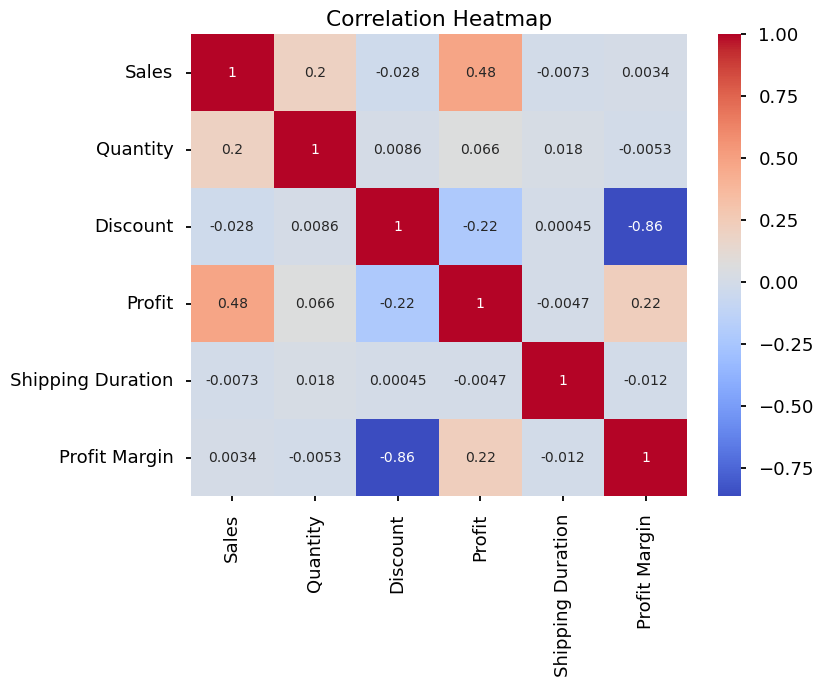

In [40]:
plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.style.use('seaborn-v0_8-talk')
plt.title('Correlation Heatmap')
plt.savefig('Correlation Heatmap.png')
plt.show()

##### Correlation Findings
The question that the graph answers: How strong is the relationship between the different variables?

The heatmap shows the relationships between the different variables. The strongest relationship is between Discount and Profit Margin, with a correlation of about -0.86, which indicates a strong negative relationship.
There is also a moderate positive relationship between Sales and Profit, with a correlation of about 0.48.
Shipping Duration has correlations close to zero with most variables, which indicates no clear linear relationship with the other variables in this dataset.

### Visualization 3 — Trend Analysis

In [41]:
monthly_sales = (df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum())
monthly_sales.head()

Order Date
2016-01    14236.895
2016-02     4519.892
2016-03    55691.009
2016-04    28295.345
2016-05    23648.287
Freq: M, Name: Sales, dtype: float64

##### Trend plot

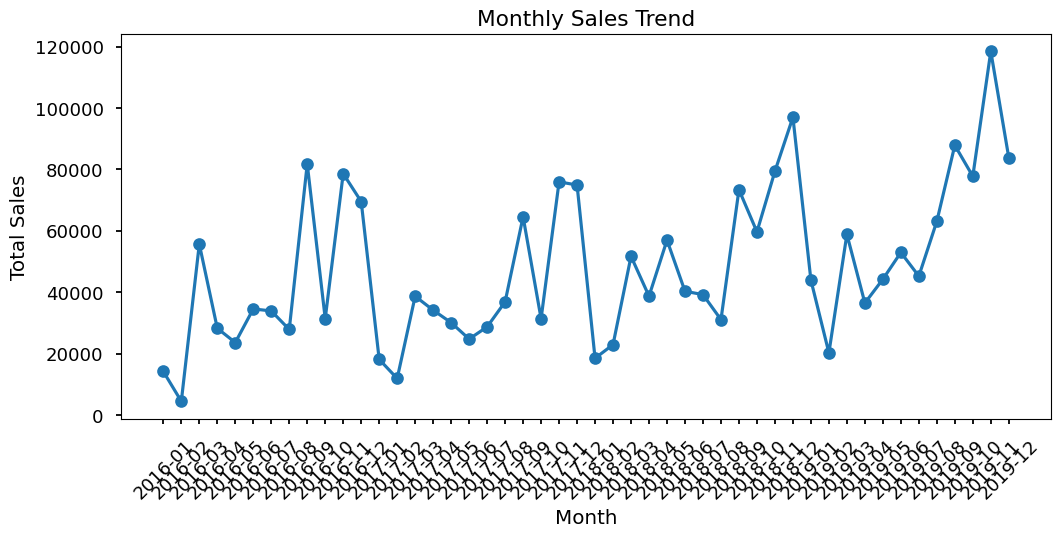

In [42]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker='o')
plt.style.use('seaborn-v0_8-talk')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.savefig('Trend plot.png')
plt.show()

### Trend Findings
The question that the chart answers: How did sales change from month to month over the time period?

The chart shows how total sales changed from month to month. Sales vary significantly across the different months, with some months showing much higher sales than others.
The highest value appears around 2019-10, with sales of approximately 118,000.
Overall, the chart shows clear fluctuations in monthly sales, with a noticeable increase toward the later part of the period.

### Visualization 4 — Sales by Category

In [43]:
sales_by_category = (df.groupby('Category')['Sales'].sum().sort_values(ascending=False))
sales_by_category

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

##### Sales by Category Barplot

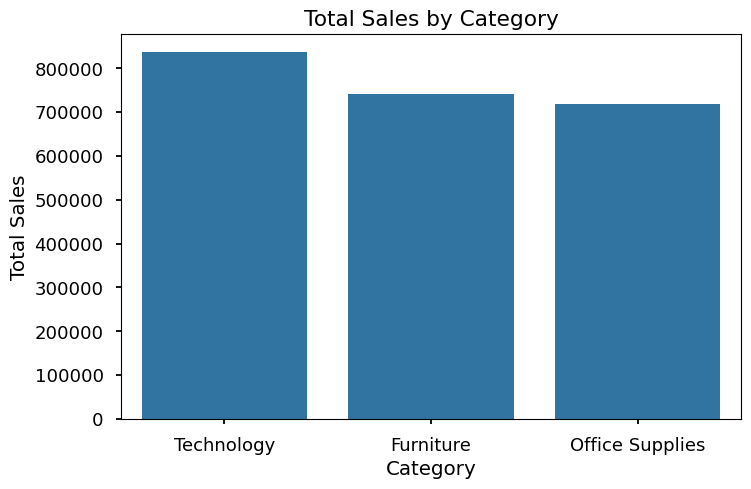

In [44]:
plt.figure(figsize=(8, 5))
sns.barplot(x=sales_by_category.index, y=sales_by_category.values)
plt.style.use('seaborn-v0_8-talk')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.savefig('Sales by Category Barplot.png')
plt.show()

### Sales by Category Findings
The question that the chart answers: Which product category achieved the highest total sales?

The chart compares total sales across the three product categories.
Technology has the highest total sales at approximately 840,000, followed by Furniture at around 745,000, and Office Supplies at around 720,000.
This means that Technology generated the highest sales among the three categories.

### Visualization 5 — Profit by Category

In [45]:
profit_by_category = (df.groupby('Category')['Profit'].sum().sort_values(ascending=False))
profit_by_category

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

##### Profit by Category Barplot

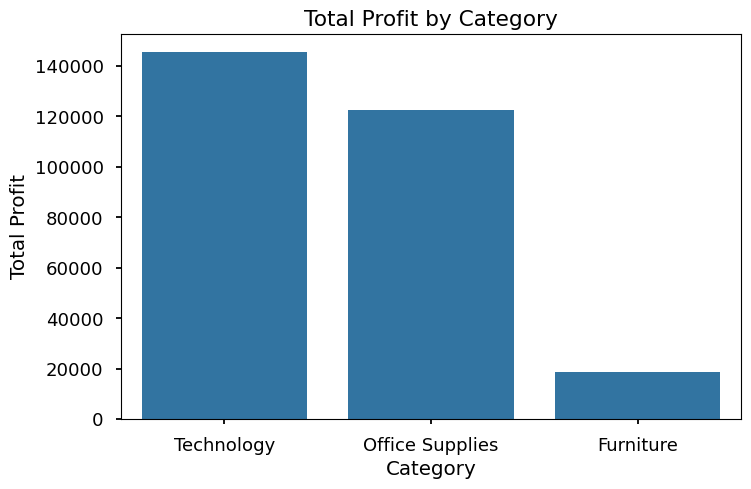

In [46]:
plt.figure(figsize=(8, 5))
sns.barplot(x=profit_by_category.index, y=profit_by_category.values)
plt.style.use('seaborn-v0_8-talk')
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.savefig('Profit by Category Barplot.png')
plt.show()

### Profit by Category Findings
The question that the chart answers: Which product category achieved the highest total profit?

The chart shows the total profit for each product category.
Technology generated the highest total profit at approximately 145,000, followed by Office Supplies at around 123,000.
Furniture generated a much lower profit of about 18,000.
Therefore, Technology had the highest total profit, while Furniture had the lowest.

### Visualization 6 — Sales by Region

In [47]:
sales_by_region = (df.groupby('Region')['Sales'].sum().sort_values(ascending=False))
sales_by_region

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

##### Sales by Region Barplot

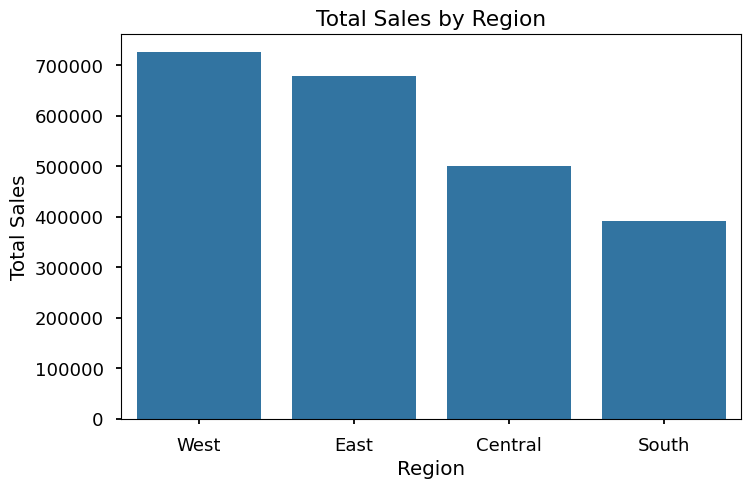

In [48]:
plt.figure(figsize=(8, 5))
sns.barplot(x=sales_by_region.index, y=sales_by_region.values)
plt.style.use('seaborn-v0_8-talk')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.savefig('Sales by Region Barplot.png')
plt.show()

### Sales by Region Findings
The question the chart answers: Which region achieved the highest total sales?

The chart compares total sales across the different regions.
The West region has the highest sales at approximately 725,000, followed by East with around 680,000.
Central has about 500,000, while South has the lowest sales at approximately 390,000.
Therefore, West is the region with the highest total sales.

### Visualization 7 — Profit by Region

In [49]:
profit_by_region = (df.groupby('Region')['Profit'].sum().sort_values(ascending=False))
profit_by_region

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64

##### Profit by Region Barplot

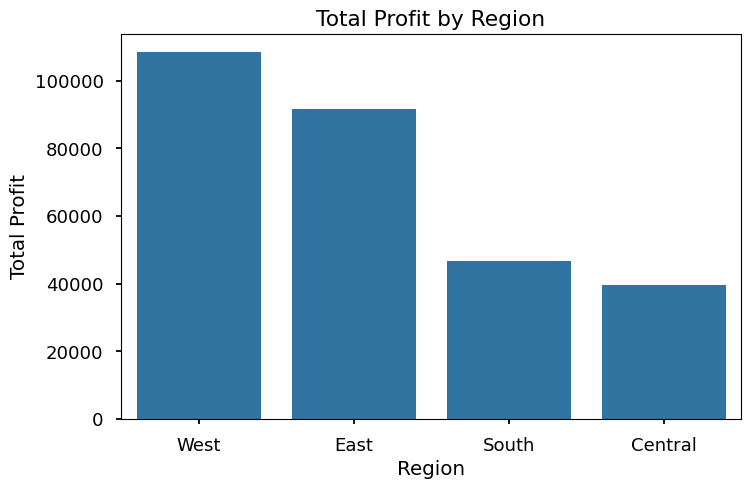

In [50]:
plt.figure(figsize=(8, 5))
sns.barplot(x=profit_by_region.index, y=profit_by_region.values)
plt.style.use('seaborn-v0_8-talk')
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit')
plt.savefig('Profit by Region Barplot.png')
plt.show()

### Profit by Region Findings
The question the chart answers: Which region achieved the highest total profit?

The chart shows the total profit for each region.
The West region generated the highest profit at approximately 109,000, followed by East with around 92,000.
South generated about 47,000, while Central had the lowest profit at around 40,000.
Therefore, West had the highest total profit, while Central had the lowest.

### Visualization 8 — Sales by Segment

In [51]:
sales_by_segment = (df.groupby('Segment')['Sales'].sum().sort_values(ascending=False))
sales_by_segment

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

##### Sales by Segment Barplot

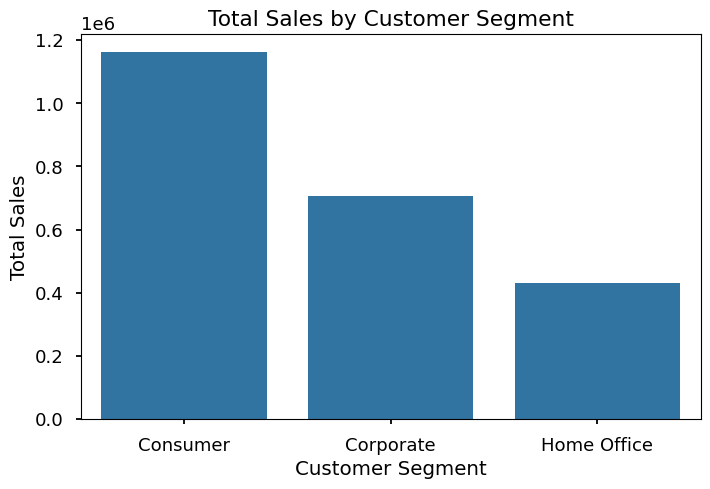

In [52]:
plt.figure(figsize=(8, 5))
sns.barplot(x=sales_by_segment.index, y=sales_by_segment.values)
plt.style.use('seaborn-v0_8-talk')
plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')
plt.savefig('Sales by Segment Barplot.png')
plt.show()

### Sales by Segment Findings
The question that the chart answers: Which type of customers brings in the highest total sales?

The chart shows total sales by customer segment.
The Consumer segment has the highest total sales at approximately 1.16 million.
It is followed by Corporate with around 710,000, while Home Office generated about 430,000.
This shows that Consumer is the largest customer segment in terms of total sales.

### Visualization 9 — Shipping Duration Distribution

In [53]:
df['Shipping Duration'].value_counts().sort_index()

Shipping Duration
0     519
1     369
2    1336
3    1004
4    2772
5    2170
6    1202
7     622
Name: count, dtype: int64

##### Shipping Duration Distribution Histplot

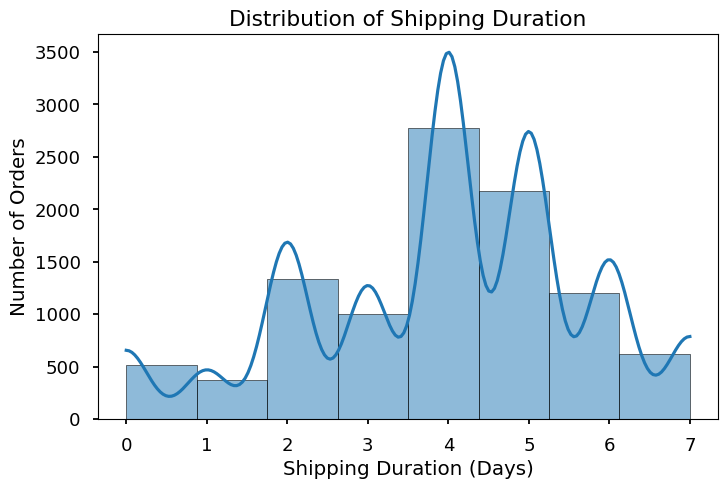

In [54]:
plt.figure(figsize=(8, 5))
sns.histplot(df["Shipping Duration"],bins=8,kde=True)
plt.style.use('seaborn-v0_8-talk')
plt.title('Distribution of Shipping Duration')
plt.xlabel('Shipping Duration (Days)')
plt.ylabel('Number of Orders')
plt.savefig('Shipping Duration Distribution Histplot.png')
plt.show()

### Shipping Duration Distribution Findings
The question the chart answers: What is the most common shipping time, and how are the orders distributed according to shipping time?

The chart shows the distribution of orders according to shipping duration.
The highest number of orders is around 4 days, followed by 5 days.
The number of orders generally decreases for longer shipping durations, especially at 7 days.
Therefore, most orders in the dataset take around 4 to 5 days to ship.

### Visualization 10 — Discount vs Profit

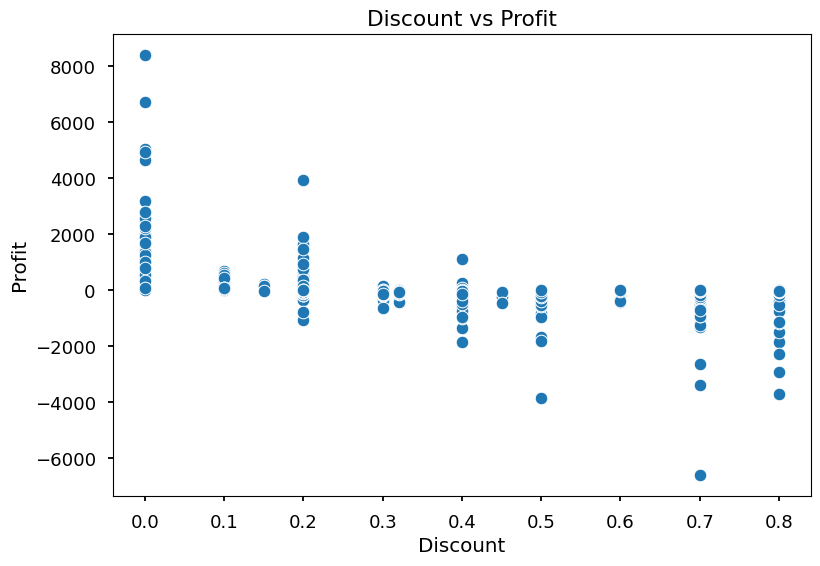

In [55]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x='Discount', y='Profit')
plt.style.use('seaborn-v0_8-talk')
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.savefig('Discount vs Profit.png')
plt.show()

### Discount vs Profit Findings
The question the chart answers: Is there a relationship between the discount rate and profit? And is an increase in discount linked to a decrease in profit?

The scatter plot shows the relationship between discount percentage and profit.
At lower discount levels, especially 0%, some observations have relatively high profits. As the discount increases, more negative profit values appear, especially at 70% and 80%.
This is consistent with the heatmap, which shows a strong negative relationship between Discount and Profit Margin.
However, the chart shows a relationship, not necessarily that discounts directly cause lower profit.

## 9. Key Performance Indicators (KPIs)

In [56]:
kpis = {
    'Total Sales': df['Sales'].sum(),
    'Total Profit': df['Profit'].sum(),
    'Total Quantity': df['Quantity'].sum(),
    'Total Orders': df['Order ID'].nunique(),
    'Average Sales per Order': df.groupby('Order ID')['Sales'].sum().mean(),
    'Average Profit Margin': df['Profit Margin'].mean(),
    'Average Shipping Duration': df['Shipping Duration'].mean()
     }

kpi_summary = pd.DataFrame(kpis.items(), columns=['KPI','Value'])
kpi_summary

,KPI,Value
0,Total Sales,2.297201e+06
1,Total Profit,2.863970e+05
2,Total Quantity,3.787300e+04
3,Total Orders,5.009000e+03
4,Average Sales per Order,4.586147e+02
5,Average Profit Margin,1.203139e+01
6,Average Shipping Duration,3.958075e+00


## 10. Object-Oriented Data Preprocessing

In [57]:
class DataPreprocessor:

    def __init__(self, dataframe):
        self.df = dataframe.copy()

    def convert_postal_code(self):
        self.df["Postal Code"] = self.df["Postal Code"].astype("object")

    def create_features(self):
        self.df["Shipping Duration"] = (
            self.df["Ship Date"] - self.df["Order Date"]
        ).dt.days

        if (self.df["Sales"] == 0).any():
            raise ValueError("Sales contains zero values.")

        self.df["Profit Margin"] = (
            self.df["Profit"] / self.df["Sales"]
        ) * 100

        self.df["Sales Performance"] = pd.qcut(
            self.df["Sales"],
            q=3,
            labels=["Low", "Medium", "High"]
        )

    def get_data(self):
        return self.df

In [58]:
preprocessor = DataPreprocessor(df)

preprocessor.convert_postal_code()
preprocessor.create_features()

processed_df = preprocessor.get_data()

In [59]:
processed_df[
    [
        "Postal Code",
        "Shipping Duration",
        "Profit Margin",
        "Sales Performance"
    ]
].head()

,Postal Code,Shipping Duration,Profit Margin,Sales Performance
0,42420,3,16.00,High
1,42420,3,30.00,High
2,90036,4,47.00,Low
3,33311,7,-40.00,High
4,33311,7,11.25,Low


## 11. Memory Optimization

In [60]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             9994 non-null   int64         
 1   Order ID           9994 non-null   object        
 2   Order Date         9994 non-null   datetime64[ns]
 3   Ship Date          9994 non-null   datetime64[ns]
 4   Ship Mode          9994 non-null   object        
 5   Customer ID        9994 non-null   object        
 6   Customer Name      9994 non-null   object        
 7   Segment            9994 non-null   object        
 8   Country/Region     9994 non-null   object        
 9   City               9994 non-null   object        
 10  State              9994 non-null   object        
 11  Postal Code        9994 non-null   object        
 12  Region             9994 non-null   object        
 13  Product ID         9994 non-null   object        
 14  Category

In [61]:
memory_before = df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f'Memory usage before optimization: {memory_before:.2f} MB')

Memory usage before optimization: 8.70 MB


## 12. Memory Optimization

In [62]:
optimized_df = df.copy()
# Convert low-cardinality text columns to the category dtype
categorical_columns = ['Ship Mode','Segment','Country/Region','Region','Category','Sub-Category']
for col in categorical_columns:
    optimized_df[col] = optimized_df[col].astype('category')
# Downcast numeric columns to the smallest dtype that can hold their values
for col in optimized_df.select_dtypes(include=['int64']).columns:
    optimized_df[col] = pd.to_numeric(optimized_df[col], downcast='integer')
for col in optimized_df.select_dtypes(include=['float64']).columns:
    optimized_df[col] = pd.to_numeric(optimized_df[col], downcast='float')

In [63]:
memory_after = optimized_df.memory_usage(deep=True).sum() / (1024 ** 2)

print(f'Memory usage before optimization: {memory_before:.2f} MB')
print(f'Memory usage after optimization: {memory_after:.2f} MB')
print(f'Memory reduction: {memory_before - memory_after:.2f} MB ({(1 - memory_after/memory_before)*100:.1f}%)')

Memory usage before optimization: 8.70 MB
Memory usage after optimization: 5.08 MB
Memory reduction: 3.61 MB (41.6%)


In [64]:
optimized_df[categorical_columns].nunique()

Ship Mode          4
Segment            3
Country/Region     1
Region             4
Category           3
Sub-Category      17
dtype: int64

## 13. Automated Analytical Report

In [65]:
report = f"""
========================================
        SUPERSTORE ANALYTICAL REPORT
========================================

Dataset Overview
----------------
Number of Records: {len(df):,}
Number of Orders: {df['Order ID'].nunique():,}
Number of Customers: {df['Customer ID'].nunique():,}

Key Performance Indicators
--------------------------
Total Sales: ${df['Sales'].sum():,.2f}
Total Profit: ${df['Profit'].sum():,.2f}
Total Quantity Sold: {df['Quantity'].sum():,}
Average Sales per Order: ${df.groupby('Order ID')['Sales'].sum().mean():,.2f}
Average Profit Margin: {df['Profit Margin'].mean():.2f}%
Average Shipping Duration: {df['Shipping Duration'].mean():.2f} days

Top Sales Category
------------------
{df.groupby('Category')['Sales'].sum().idxmax()}

Top Profit Category
-------------------
{df.groupby('Category')['Profit'].sum().idxmax()}

Top Sales Region
----------------
{df.groupby('Region')['Sales'].sum().idxmax()}

Top Profit Region
-----------------
{df.groupby('Region')['Profit'].sum().idxmax()}

Top Customer Segment by Sales
-----------------------------
{df.groupby('Segment')['Sales'].sum().idxmax()}

========================================
"""

print(report)


        SUPERSTORE ANALYTICAL REPORT

Dataset Overview
----------------
Number of Records: 9,994
Number of Orders: 5,009
Number of Customers: 793

Key Performance Indicators
--------------------------
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Quantity Sold: 37,873
Average Sales per Order: $458.61
Average Profit Margin: 12.03%
Average Shipping Duration: 3.96 days

Top Sales Category
------------------
Technology

Top Profit Category
-------------------
Technology

Top Sales Region
----------------
West

Top Profit Region
-----------------
West

Top Customer Segment by Sales
-----------------------------
Consumer




## 14. Export

In [66]:
optimized_df.to_csv('data/Superstore_Cleaned.csv',index=False)

In [67]:
kpi_summary.to_csv('outputs/Superstore_KPI_Summary.csv',index=False)

In [68]:
with open('outputs/Superstore_Analytical_Report.txt', 'w', encoding='utf-8') as file:file.write(report)